In [3]:
from google.colab import files
uploaded = files.upload()

Saving diabetic_cleaned_v1.csv to diabetic_cleaned_v1 (1).csv


In [11]:
import pandas as pd
df = pd.read_csv('diabetic_cleaned_v1.csv')
df.head()
df.shape

(69990, 19)

In [12]:
# In case readmitted_30days isn't already in your CSV, create it
df['readmitted_30days'] = (df['readmitted'] == '<30').astype(int)

# Basic info — nulls, dtypes
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69990 entries, 0 to 69989
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   encounter_id              69990 non-null  int64 
 1   patient_nbr               69990 non-null  int64 
 2   race                      69990 non-null  object
 3   age                       69990 non-null  object
 4   time_in_hospital          69990 non-null  int64 
 5   num_lab_procedures        69990 non-null  int64 
 6   num_procedures            69990 non-null  int64 
 7   num_medications           69990 non-null  int64 
 8   number_outpatient         69990 non-null  int64 
 9   number_emergency          69990 non-null  int64 
 10  number_inpatient          69990 non-null  int64 
 11  diag_1                    69990 non-null  object
 12  number_diagnoses          69990 non-null  int64 
 13  insulin                   69990 non-null  object
 14  diabetesMed           

,0
encounter_id,0
patient_nbr,0
race,0
age,0
time_in_hospital,0
num_lab_procedures,0
num_procedures,0
num_medications,0
number_outpatient,0
number_emergency,0


In [14]:
# Correlation Analysis
# Select numeric columns relevant to readmission
numeric_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                 'num_medications', 'number_outpatient', 'number_emergency',
                 'number_inpatient', 'number_diagnoses', 'readmitted_30days']

corr_matrix = df[numeric_cols].corr()

# See what correlates most with readmission
print(corr_matrix['readmitted_30days'].sort_values(ascending=False))

readmitted_30days     1.000000
number_inpatient      0.100278
time_in_hospital      0.055824
number_diagnoses      0.045610
num_medications       0.036198
num_lab_procedures    0.032063
number_emergency      0.028022
number_outpatient     0.008633
num_procedures       -0.000280
Name: readmitted_30days, dtype: float64


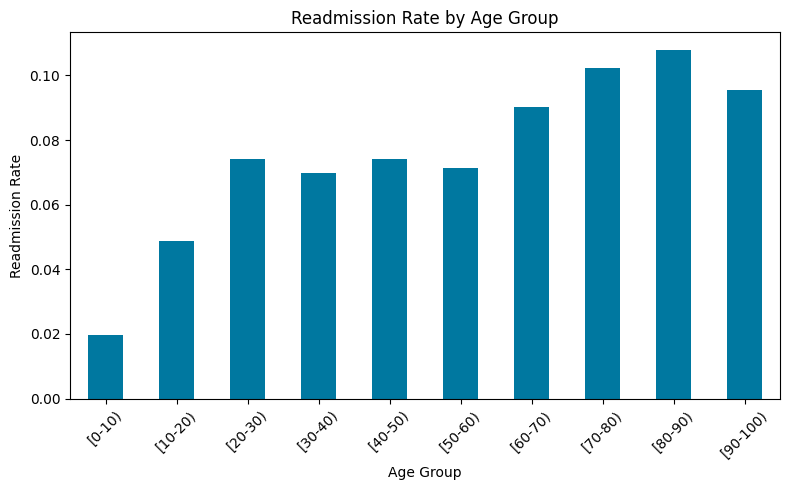

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chart 1 — Readmission Rate by Age Group
plt.figure(figsize=(8,5))
age_readmit = df.groupby('age')['readmitted_30days'].mean().sort_index()
age_readmit.plot(kind='bar', color='#0078A0')
plt.title('Readmission Rate by Age Group')
plt.ylabel('Readmission Rate')
plt.xlabel('Age Group')
plt.xticks(rotation=45)
plt.tight_layout()
# plt.savefig('readmission_by_age.png', dpi=150)
plt.show()

/tmp/ipykernel_1356/4037860096.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='readmitted_30days', y='time_in_hospital', data=df, palette=['#0078A0', '#D9534F'])


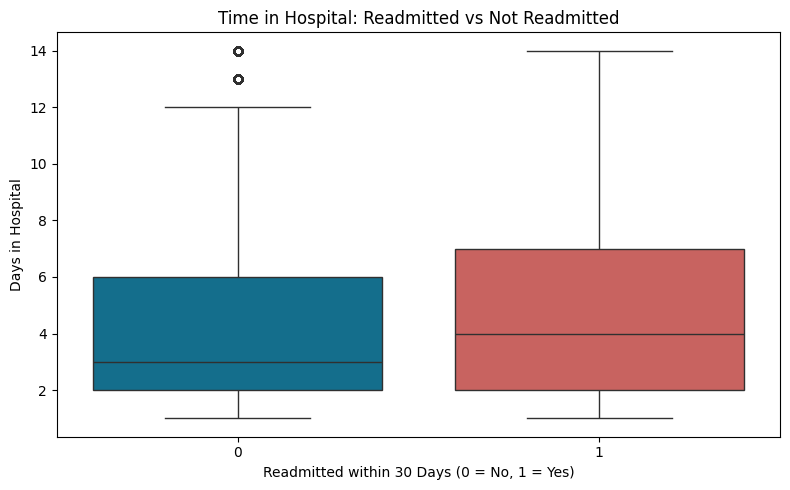

In [23]:
# Chart 2 — Boxplot: Time in Hospital vs Readmission
plt.figure(figsize=(8,5))
sns.boxplot(x='readmitted_30days', y='time_in_hospital', data=df, palette=['#0078A0', '#D9534F'])
plt.title('Time in Hospital: Readmitted vs Not Readmitted')
plt.xlabel('Readmitted within 30 Days (0 = No, 1 = Yes)')
plt.ylabel('Days in Hospital')
plt.tight_layout()
# plt.savefig('boxplot_stay_readmission.png', dpi=150)
plt.show()

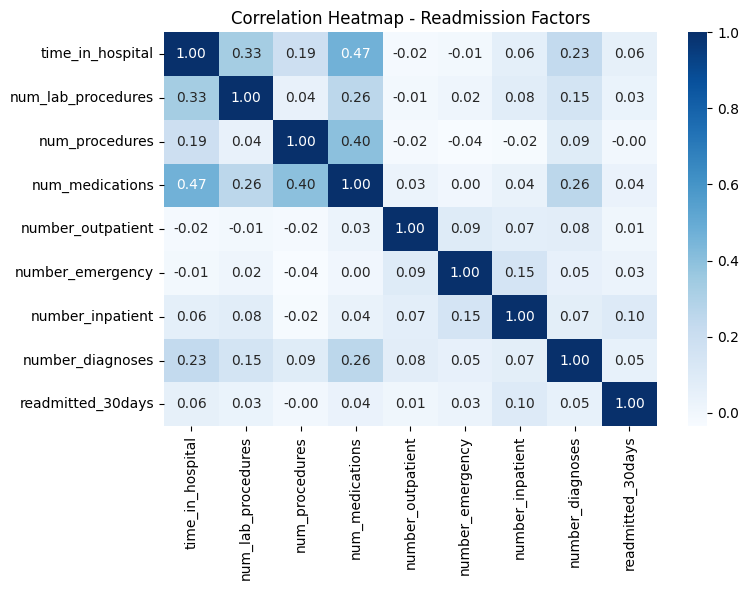

In [24]:
# Heatmap of correlation matrix — nice visual for README
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap - Readmission Factors')
plt.tight_layout()
# plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()